# Generación de Embeddings de Texto para LightGBM

**Objetivo**: Extraer embeddings del campo `Description` usando DistilBERT pre-entrenado y agregarlos como features al dataset tabular para LightGBM.

**¿Por qué embeddings en lugar de fine-tuning + blending?**
- LightGBM puede aprender **interacciones** entre features textuales y tabulares
- Un solo modelo, sin problemas de escalas incompatibles entre scores
- Los embeddings pre-entrenados ya capturan semántica rica sin riesgo de overfitting
- PCA reduce la dimensionalidad de 768 a ~32 features manejables

**Pipeline**:
1. Cargar datos con el mismo split que el estudio LGB de Optuna
2. Tokenizar las descripciones con DistilBERT
3. Extraer embeddings del token [CLS] (768 dims)
4. Reducir dimensionalidad con PCA
5. Guardar para integrar con el dataset tabular

#### **Instalar Modulos**

conda install datasets=="2.20.0"

conda install transformers=="4.40.1"

conda install numpy=="1.26.4"

pip install scikit-learn joblib optuna

In [1]:
# Data processing
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Modeling
import torch
from transformers import DistilBertTokenizerFast, DistilBertModel

# Progress bar
from tqdm.auto import tqdm

# Persistence
from joblib import load, dump

# Optuna (para cargar el mismo split)
import optuna

from utils import get_artifact_filename

# Verificamos que CUDA está funcional
print(f'CUDA disponible: {torch.cuda.is_available()}')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Device: {device}')

c:\Users\keive\miniconda3\envs\ldi2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA disponible: False
Device: cpu


## 1. Cargar datos con el mismo split que LightGBM

In [2]:
# Paths
BASE_DIR = '../'
PATH_TO_TRAIN = os.path.join(BASE_DIR, "input/petfinder-adoption-prediction/train/train.csv")
PATH_TO_WORK = os.path.join(BASE_DIR, "work")
PATH_TO_OPTUNA_ARTIFACTS = os.path.join(BASE_DIR, "work/optuna_artifacts")

# Parametros
SEED = 42
N_PCA_COMPONENTS = 32  # Dimensiones finales del embedding (ajustable)
BATCH_SIZE = 64
MAX_LENGTH = 512

In [3]:
# Cargar datos
df = pd.read_csv(PATH_TO_TRAIN)
print(f'Total de registros: {len(df)}')
print(f'Registros sin descripción: {df["Description"].isnull().sum()}')

# Usar el mismo split que el estudio LGB para comparabilidad
try:
    study_lgb = optuna.create_study(
        direction='maximize',
        storage="sqlite:///../work/db.sqlite3",
        study_name="04 - LGB Multiclass CV",
        load_if_exists=True
    )
    lgb_test_dataset = load(os.path.join(PATH_TO_OPTUNA_ARTIFACTS, get_artifact_filename(study_lgb, 'test')))
    test_pet_ids = lgb_test_dataset.PetID.tolist()
    
    train_df = df[~df.PetID.isin(test_pet_ids)].reset_index(drop=True)
    test_df = df[df.PetID.isin(test_pet_ids)].reset_index(drop=True)
    print(f'Usando split de Optuna LGB')
except Exception as e:
    print(f'No se encontró el estudio LGB ({e}), usando train_test_split')
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df.AdoptionSpeed)

print(f'Train: {len(train_df)}, Test: {len(test_df)}')

Total de registros: 14993
Registros sin descripción: 13
No se encontró el estudio LGB ((sqlite3.OperationalError) unable to open database file
(Background on this error at: https://sqlalche.me/e/20/e3q8)), usando train_test_split
Train: 11994, Test: 2999


## 2. Cargar modelo DistilBERT pre-entrenado

Usamos el modelo **pre-entrenado** (sin fine-tuning) para extraer embeddings.
Esto evita el overfitting y los embeddings genéricos ya capturan buena semántica.

In [4]:
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
model = DistilBertModel.from_pretrained('distilbert-base-uncased')
model = model.to(device)
model.eval()
print(f'Modelo cargado - dimensión del embedding: {model.config.hidden_size}')

c:\Users\keive\miniconda3\envs\ldi2\Lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\keive\miniconda3\envs\ldi2\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\keive\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an a

Modelo cargado - dimensión del embedding: 768


## 3. Función para extraer embeddings

Extraemos el embedding del token **[CLS]** (primera posición), que representa un resumen de toda la secuencia.

In [5]:
def extract_embeddings(texts, tokenizer, model, device, batch_size=64, max_length=512):
    """Extrae embeddings [CLS] de DistilBERT para una lista de textos.
    
    Args:
        texts: Lista de strings
        tokenizer: Tokenizer de DistilBERT
        model: Modelo DistilBERT
        device: 'cuda' o 'cpu'
        batch_size: Tamaño del batch
        max_length: Longitud máxima de tokenización
    
    Returns:
        numpy array de shape (n_texts, 768)
    """
    all_embeddings = []
    
    for i in tqdm(range(0, len(texts), batch_size), desc='Extrayendo embeddings'):
        batch_texts = texts[i:i+batch_size]
        
        # Tokenizar
        encoded = tokenizer(
            batch_texts, 
            padding=True, 
            truncation=True, 
            max_length=max_length, 
            return_tensors='pt'
        ).to(device)
        
        # Extraer embeddings sin calcular gradientes
        with torch.no_grad():
            outputs = model(**encoded)
        
        # Tomar el embedding del token [CLS] (posición 0)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)
    
    return np.vstack(all_embeddings)

## 4. Extraer embeddings para train y test

Para las descripciones nulas, usamos un string vacío (DistilBERT generará un embedding "neutral").

In [6]:
# Preparar textos (reemplazar NaN con string vacío)
train_texts = train_df['Description'].fillna('').tolist()
test_texts = test_df['Description'].fillna('').tolist()

print(f'Extrayendo embeddings para {len(train_texts)} textos de train...')
train_embeddings = extract_embeddings(train_texts, tokenizer, model, device, BATCH_SIZE, MAX_LENGTH)
print(f'Shape train embeddings: {train_embeddings.shape}')

print(f'\nExtrayendo embeddings para {len(test_texts)} textos de test...')
test_embeddings = extract_embeddings(test_texts, tokenizer, model, device, BATCH_SIZE, MAX_LENGTH)
print(f'Shape test embeddings: {test_embeddings.shape}')

Extrayendo embeddings para 11994 textos de train...


Extrayendo embeddings: 100%|██████████| 188/188 [1:15:47<00:00, 24.19s/it]


Shape train embeddings: (11994, 768)

Extrayendo embeddings para 2999 textos de test...


Extrayendo embeddings: 100%|██████████| 47/47 [18:50<00:00, 24.06s/it]

Shape test embeddings: (2999, 768)


## 5. Reducir dimensionalidad con PCA

768 features es demasiado para LightGBM (riesgo de overfitting y lentitud).
PCA reduce a N_PCA_COMPONENTS manteniendo la mayor varianza posible.

In [7]:
# Estandarizar antes de PCA
scaler = StandardScaler()
train_embeddings_scaled = scaler.fit_transform(train_embeddings)
test_embeddings_scaled = scaler.transform(test_embeddings)

# Aplicar PCA
pca = PCA(n_components=N_PCA_COMPONENTS, random_state=SEED)
train_pca = pca.fit_transform(train_embeddings_scaled)
test_pca = pca.transform(test_embeddings_scaled)

explained_var = pca.explained_variance_ratio_.sum()
print(f'PCA: {N_PCA_COMPONENTS} componentes explican {explained_var:.1%} de la varianza')
print(f'Shape train PCA: {train_pca.shape}')
print(f'Shape test PCA: {test_pca.shape}')

PCA: 32 componentes explican 72.0% de la varianza
Shape train PCA: (11994, 32)
Shape test PCA: (2999, 32)


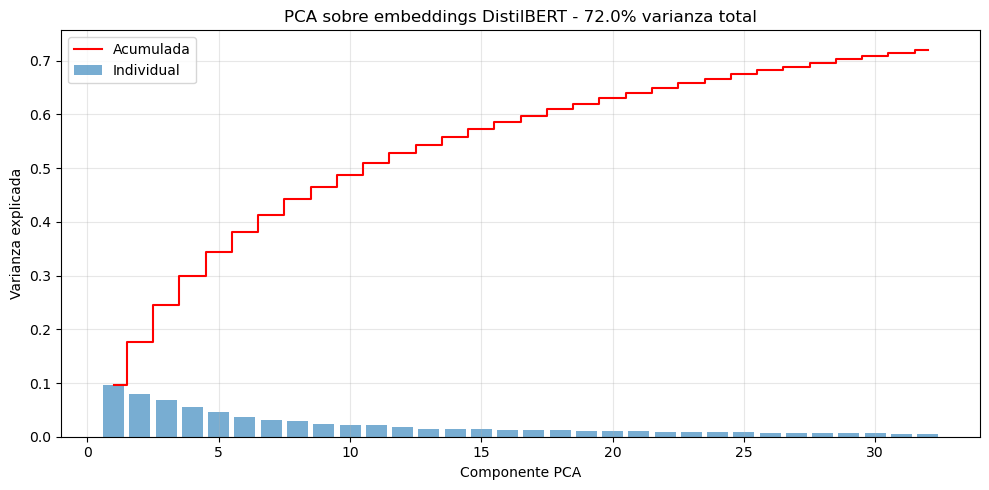

In [8]:
# Visualizar varianza explicada acumulada
import matplotlib.pyplot as plt

cumvar = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(10, 5))
plt.bar(range(1, N_PCA_COMPONENTS+1), pca.explained_variance_ratio_, alpha=0.6, label='Individual')
plt.step(range(1, N_PCA_COMPONENTS+1), cumvar, where='mid', label='Acumulada', color='red')
plt.xlabel('Componente PCA')
plt.ylabel('Varianza explicada')
plt.title(f'PCA sobre embeddings DistilBERT - {explained_var:.1%} varianza total')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Crear DataFrames con embeddings

In [9]:
# Crear columnas con nombres descriptivos
emb_cols = [f'text_emb_{i}' for i in range(N_PCA_COMPONENTS)]

train_emb_df = pd.DataFrame(train_pca, columns=emb_cols)
train_emb_df['PetID'] = train_df['PetID'].values

test_emb_df = pd.DataFrame(test_pca, columns=emb_cols)
test_emb_df['PetID'] = test_df['PetID'].values

# Combinar train + test embeddings en un solo DataFrame
all_emb_df = pd.concat([train_emb_df, test_emb_df], ignore_index=True)
print(f'DataFrame de embeddings: {all_emb_df.shape}')
all_emb_df.head()

DataFrame de embeddings: (14993, 33)


,text_emb_0,text_emb_1,text_emb_2,text_emb_3,text_emb_4,text_emb_5,text_emb_6,text_emb_7,text_emb_8,text_emb_9,...,text_emb_23,text_emb_24,text_emb_25,text_emb_26,text_emb_27,text_emb_28,text_emb_29,text_emb_30,text_emb_31,PetID
0,2.072741,-8.515498,-0.093132,-8.036955,-0.142917,1.415956,-6.363506,-2.653756,-3.695580,-0.799188,...,2.866547,-0.378620,4.239963,1.011876,-1.046966,-3.410402,3.869660,3.105518,-5.487539,23b64fe21
1,-3.410144,15.328326,-4.035799,0.905904,1.085762,-11.236814,3.555565,5.152394,-1.404166,-7.912014,...,1.192327,-0.162722,0.328924,-0.526796,-1.409725,2.954501,0.635322,4.291424,2.738870,6e09bfe1f
2,-18.901819,-8.106945,2.010976,-3.346947,-6.737272,-8.666144,13.513362,-1.376555,-3.326967,2.069380,...,-2.657416,1.443029,0.698790,-3.804487,0.392703,-3.075350,-3.337360,-4.431737,4.166775,48a44eac5
3,-23.214592,3.795494,-7.698166,5.665525,-1.680050,9.259562,1.625514,-4.995527,4.380379,-5.171898,...,-2.329046,4.294311,0.843405,-3.924637,1.324947,-1.068457,0.048958,2.238770,-0.014622,ae219ff80
4,-16.317345,6.121364,-7.554836,8.936792,-0.561900,7.197980,2.714209,-4.854939,3.967100,2.241368,...,-4.284716,1.266900,-1.257621,-2.153600,1.524890,-1.291379,1.351535,1.788095,0.720398,e13c47053


## 7. Guardar artefactos

In [10]:
# Guardar embeddings, scaler y PCA
os.makedirs(PATH_TO_WORK, exist_ok=True)

emb_path = os.path.join(PATH_TO_WORK, 'text_embeddings_pca.joblib')
dump(all_emb_df, emb_path)
print(f'Embeddings guardados en: {emb_path}')

scaler_path = os.path.join(PATH_TO_WORK, 'text_emb_scaler.joblib')
dump(scaler, scaler_path)
print(f'Scaler guardado en: {scaler_path}')

pca_path = os.path.join(PATH_TO_WORK, 'text_emb_pca.joblib')
dump(pca, pca_path)
print(f'PCA guardado en: {pca_path}')

Embeddings guardados en: ../work\text_embeddings_pca.joblib
Scaler guardado en: ../work\text_emb_scaler.joblib
PCA guardado en: ../work\text_emb_pca.joblib


## 8. Demo: Integrar con dataset tabular y entrenar LightGBM

Ejemplo rápido de cómo usar los embeddings con LightGBM.

In [ ]:
from sklearn.metrics import cohen_kappa_score

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    print('LightGBM no instalado. Instalar con: pip install lightgbm')
    HAS_LGB = False

In [ ]:
if HAS_LGB:
    # Features tabulares originales
    feature_cols = ['Type', 'Age', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3',
                    'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized',
                    'Health', 'Quantity', 'Fee', 'State', 'VideoAmt', 'PhotoAmt']
    target_col = 'AdoptionSpeed'
    
    # --- Modelo SIN embeddings ---
    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()
    y_train = train_df[target_col]
    y_test = test_df[target_col]
    
    # Rellenar PhotoAmt NaN
    X_train['PhotoAmt'] = X_train['PhotoAmt'].fillna(0)
    X_test['PhotoAmt'] = X_test['PhotoAmt'].fillna(0)
    
    model_base = lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=31,
        random_state=SEED, verbose=-1, n_jobs=-1
    )
    model_base.fit(X_train, y_train)
    pred_base = model_base.predict(X_test)
    kappa_base = cohen_kappa_score(y_test, pred_base, weights='quadratic')
    print(f'LightGBM SIN embeddings - QWK: {kappa_base:.4f}')
    
    # --- Modelo CON embeddings ---
    X_train_emb = pd.concat([X_train.reset_index(drop=True), train_emb_df[emb_cols].reset_index(drop=True)], axis=1)
    X_test_emb = pd.concat([X_test.reset_index(drop=True), test_emb_df[emb_cols].reset_index(drop=True)], axis=1)
    
    model_emb = lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=31,
        random_state=SEED, verbose=-1, n_jobs=-1
    )
    model_emb.fit(X_train_emb, y_train)
    pred_emb = model_emb.predict(X_test_emb)
    kappa_emb = cohen_kappa_score(y_test, pred_emb, weights='quadratic')
    print(f'LightGBM CON embeddings - QWK: {kappa_emb:.4f}')
    
    print(f'\nMejora: {kappa_emb - kappa_base:+.4f} ({(kappa_emb/kappa_base - 1)*100:+.1f}%)')

In [ ]:
if HAS_LGB:
    # Feature importance de las top 30 features
    importances = pd.DataFrame({
        'feature': X_train_emb.columns,
        'importance': model_emb.feature_importances_
    }).sort_values('importance', ascending=True).tail(30)
    
    plt.figure(figsize=(10, 8))
    colors = ['#2196F3' if 'text_emb' in f else '#FF9800' for f in importances['feature']]
    plt.barh(importances['feature'], importances['importance'], color=colors)
    plt.xlabel('Importance')
    plt.title('Top 30 Feature Importances (Naranja=Tabular, Azul=Embedding)')
    plt.tight_layout()
    plt.show()

## 9. Cómo integrar en tu notebook de LightGBM

Para usar estos embeddings en tu pipeline existente:

```python
from joblib import load

# Cargar embeddings pre-calculados
emb_df = load('../work/text_embeddings_pca.joblib')

# Merge con tu dataset tabular por PetID
train_df = train_df.merge(emb_df, on='PetID', how='left')
test_df = test_df.merge(emb_df, on='PetID', how='left')

# Agregar las columnas text_emb_0 ... text_emb_31 a tus features
emb_cols = [c for c in emb_df.columns if c.startswith('text_emb_')]
feature_cols = feature_cols + emb_cols

# Rellenar NaN para mascotas sin embedding
train_df[emb_cols] = train_df[emb_cols].fillna(0)
test_df[emb_cols] = test_df[emb_cols].fillna(0)
```

### Tips para optimizar:
- Probar con diferentes valores de `N_PCA_COMPONENTS` (16, 32, 64, 128)
- Usar Optuna para buscar el número óptimo de componentes
- Si ya tenés un modelo DistilBERT fine-tuneado, podés usarlo en lugar del pre-entrenado
- Considerar usar mean pooling en lugar de [CLS] token